# DAY 2 — 최종 모델 개발 및 평가

개발 버전 **0.2.0**, 실험 **v02_submission**. 첫 100사이클에서 계산한 ΔQ log분산 한 개로 원본 Cycle Life를 예측한다.
기존 Batch 1 그룹 분할을 유지하고 LinearRegression·Ridge·Elastic Net의 **69개 설정**을 개발 CV로 비교한다.
Hold-out 평가 후 설정을 고정해 Batch 1 전체로 재학습하고 Batch 2를 최종 평가한다. Batch 3은 선택 과제로 이번 제출에 포함하지 않는다.

원본 MAT 없이 저장소의 피처 CSV로 실행할 수 있다. 이미 완료된 실험이 있으면 저장 결과만 읽어 표시하고 Test를 다시 예측하지 않는다.

In [1]:
from pathlib import Path
import sys, json
import numpy as np
import pandas as pd
from IPython.display import display, Image

ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / 'src/modeling_submission.py').exists()
             and (p / 'outputs/day1/early_feature_candidates.csv').exists()), None)
if ROOT is None:
    raise FileNotFoundError('battery-project 루트 또는 notebooks/에서 실행하세요.')
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from src.modeling_submission import run, load_results, confirmed_config
from src.day2_final_figures import create_figures
pd.set_option('display.max_columns', None)
print('프로젝트:', ROOT)
print('실험: v02_submission / 개발 버전: 0.2.0')

프로젝트: /Users/lwh/Desktop/battery-project
실험: v02_submission / 개발 버전: 0.2.0


## 1. 사용자 확정 설계

그룹 20% Hold-out·개발 5-fold CV·seed 42의 저장 분할을 재사용한다. 스케일러는 각 fold train에서만 fit한다.
`alpha = 10^-4 ... 10^4`의 17개 로그 간격 값과 Elastic Net의 `l1_ratio=0.1, 0.5, 0.9`를 비교한다.
선택 기준은 **5개 validation fold MAPE의 산술평균 최소**다. OLS/규제 모델의 학습 손실과 검증 MAPE는 별개다.
프로토콜·셀 ID·배치 ID는 피처에 넣지 않는다. 타깃 변환·셀 제외·보간·clipping은 적용하지 않는다.

In [2]:
design = confirmed_config()
print(json.dumps(design, ensure_ascii=False, indent=2))
print('참고 분할:', 'artifacts/splits/batch1_group_holdout_cv.json')

{
  "schema_version": 1,
  "experiment_id": "v02_submission",
  "decision_status": "user_approved_final_submission_design",
  "source_csv": "outputs/day1/early_feature_candidates.csv",
  "source_csv_sha256": "dc4e7979037b974d68e88eebc66232b2221095154e747b8f2b15d32a17ddfe21",
  "split_manifest": "artifacts/splits/batch1_group_holdout_cv.json",
  "split_id": "5ac6e1b0a3010116290b6d6a5675dc54a9ecc17867404b891c2d9989369b9fa1",
  "random_state": 42,
  "features": [
    "delta_q_log10var"
  ],
  "target": "cycle_life",
  "target_transform": "none",
  "observation_scope": "first 100 cycles; actual cycles 10 and 100 for this feature",
  "feature_definition": "log10(var(Qdlin_100-Qdlin_10, ddof=0)) on the verified original common 1000-point Vdlin grid; numeric Ah^2 variance; no epsilon",
  "preprocessing": "StandardScaler fitted on each training partition only",
  "imputation": "none",
  "cell_exclusion": "none",
  "prediction_clipping": false,
  "candidate_models": [
    "LinearRegression",
  

## 2. 비교·선택과 평가

최초 실행은 CV로 선택 설정을 저장한 뒤 개발 35셀 학습 모델로 Hold-out 11셀을 평가한다.
이후 같은 설정으로 Batch 1 전체 46셀에 재학습해 Batch 2의 원본 47셀을 예측한다. 성능은 유효 타깃 39셀 기준이며 미상 8셀은 보존한다.
이미 저장된 결과가 있다면 아래 셀은 **읽기만** 수행한다. 기존 실험을 덮어쓰거나 Test 성능으로 재튜닝하지 않는다.

In [3]:
artifact_dir = ROOT / 'artifacts/experiments/v02_submission'
if (artifact_dir / 'metrics.json').exists():
    result = load_results(ROOT)
    print('기존 확정 실험을 읽음: 새 모델 학습·Test 예측 없음')
else:
    result = run(ROOT)
    print('최초 제출 실험 실행 완료')
summary = result['summary']
display(result['candidate_scores'])
print('선택 설정:', summary['winner'])
display(result['cv_metrics'])

기존 확정 실험을 읽음: 새 모델 학습·Test 예측 없음


,candidate_id,model_class,alpha,l1_ratio,mean_mape_percent,mape_percent_sample_sd,mean_mae_cycles,mean_rmse_cycles,selected,fold_1_mape_percent,fold_2_mape_percent,fold_3_mape_percent,fold_4_mape_percent,fold_5_mape_percent
0,1,LinearRegression,NaN,NaN,7.239794,2.471760,60.140841,72.260132,False,10.386223,5.949656,6.145374,4.472865,9.244854
1,2,Ridge,0.000100,NaN,7.239785,2.471772,60.140774,72.260096,False,10.386227,5.949678,6.145333,4.472831,9.244854
2,3,Ridge,0.000316,NaN,7.239763,2.471799,60.140627,72.260018,False,10.386235,5.949725,6.145246,4.472758,9.244853
3,4,Ridge,0.001000,NaN,7.239696,2.471882,60.140165,72.259774,False,10.386261,5.949875,6.144971,4.472525,9.244849
4,5,Ridge,0.003162,NaN,7.239484,2.472147,60.138702,72.259003,False,10.386343,5.950350,6.144101,4.471789,9.244840
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64,65,ElasticNet,3162.277660,0.5,18.902876,5.372646,146.076912,174.203473,False,14.300346,21.927760,20.855965,25.088657,12.341653
65,66,ElasticNet,3162.277660,0.9,18.902876,5.372646,146.076912,174.203473,False,14.300346,21.927760,20.855965,25.088657,12.341653
66,67,ElasticNet,10000.000000,0.1,18.902876,5.372646,146.076912,174.203473,False,14.300346,21.927760,20.855965,25.088657,12.341653
67,68,ElasticNet,10000.000000,0.5,18.902876,5.372646,146.076912,174.203473,False,14.300346,21.927760,20.855965,25.088657,12.341653


선택 설정: {'model_class': 'ElasticNet', 'alpha': 0.1, 'l1_ratio': 0.5}


,fold,n_train_cells,n_validation_cells,n_train_groups,n_validation_groups,mape_percent,mae_cycles,rmse_cycles
0,1,28,7,14,4,10.436888,83.839721,105.185496
1,2,27,8,14,4,6.233746,54.812167,70.840685
2,3,27,8,14,4,5.624015,49.589476,61.163159
3,4,29,6,15,3,3.999564,30.705669,38.005564
4,5,29,6,15,3,9.238551,77.106216,85.997017


## 3. 과제 형식의 성능표

Train은 CV 평균이다. Valid는 개발 35셀 모델, Test는 Batch 1 전체 46셀 재학습 모델의 성능이다.
Gap은 **Valid−CV, Test−Valid, Test−9.1**, 단위 %p로 보고한다. 양수는 오차 증가를 뜻한다.
Valid-Test에는 배치 변화와 최종 재학습 범위의 변화가 함께 포함된다. Target 비교는 Batch 2 대상이다.
CV는 선택에 사용된 점수라 낙관 편향이 가능하고 fold SD는 신뢰구간이 아니다.

In [4]:
display(result['performance'])
print('CV:', summary['train_cv'])
print('Hold-out:', summary['holdout'])
print('Batch 2:', summary['batch2'])
print('Gap (%p):', summary['gaps_percent_points'])

,index,mape_percent,unit,note,mae_cycles,rmse_cycles
0,Train (Batch 1 CV),7.106553,%,35 development cells; five-fold unweighted val...,59.210650,72.238384
1,Valid (Batch 1 Hold-out),12.416026,%,11 cells; winner fitted on development 35 cells,115.079215,138.187624
2,Test (Batch 2),33.370421,%,39 known targets of 47 cells; same settings re...,163.891327,176.636752
3,Gap (Train-Valid),5.309473,%p,"Valid-CV; positive suggests poorer validation,...",NaN,NaN
4,Gap (Valid-Test),20.954395,%p,Test-Valid; different batches AND fit sample c...,NaN,NaN
5,Gap (Target-Test),24.270421,%p,"Batch 2 Test-9.1; assignment comparison, not i...",NaN,NaN


CV: {'n_cells': 35, 'n_protocol_groups': 18, 'n_folds': 5, 'mape_percent_mean': 7.106552982822262, 'mape_percent_sample_sd': 2.6575197264466093, 'mae_cycles_fold_mean': 59.21064989782042, 'rmse_cycles_fold_mean': 72.23838407529982, 'pooled_oof': {'mape_percent': 7.067114295407732, 'mae_cycles': 59.11321440494419, 'rmse_cycles': 75.69903862335954}, 'aggregation': 'unweighted arithmetic validation-fold mean', 'limitations': 'Used for candidate selection; not nested/unbiased post-selection CV. Fold sample SD is not a confidence interval.'}
Hold-out: {'n_cells': 11, 'n_protocol_groups': 5, 'model_fit_n_cells': 35, 'mape_percent': 12.416025834719544, 'mae_cycles': 115.07921479601637, 'rmse_cycles': 138.1876240625751}
Batch 2: {'n_original_cells': 47, 'n_predicted_cells': 47, 'n_evaluated_cells': 39, 'n_unknown_targets': 8, 'unknown_target_cell_ids': [22, 23, 35, 36, 37, 38, 39, 40], 'model_fit_n_cells': 46, 'mape_percent': 33.37042130933356, 'mae_cycles': 163.89132689842134, 'rmse_cycles': 

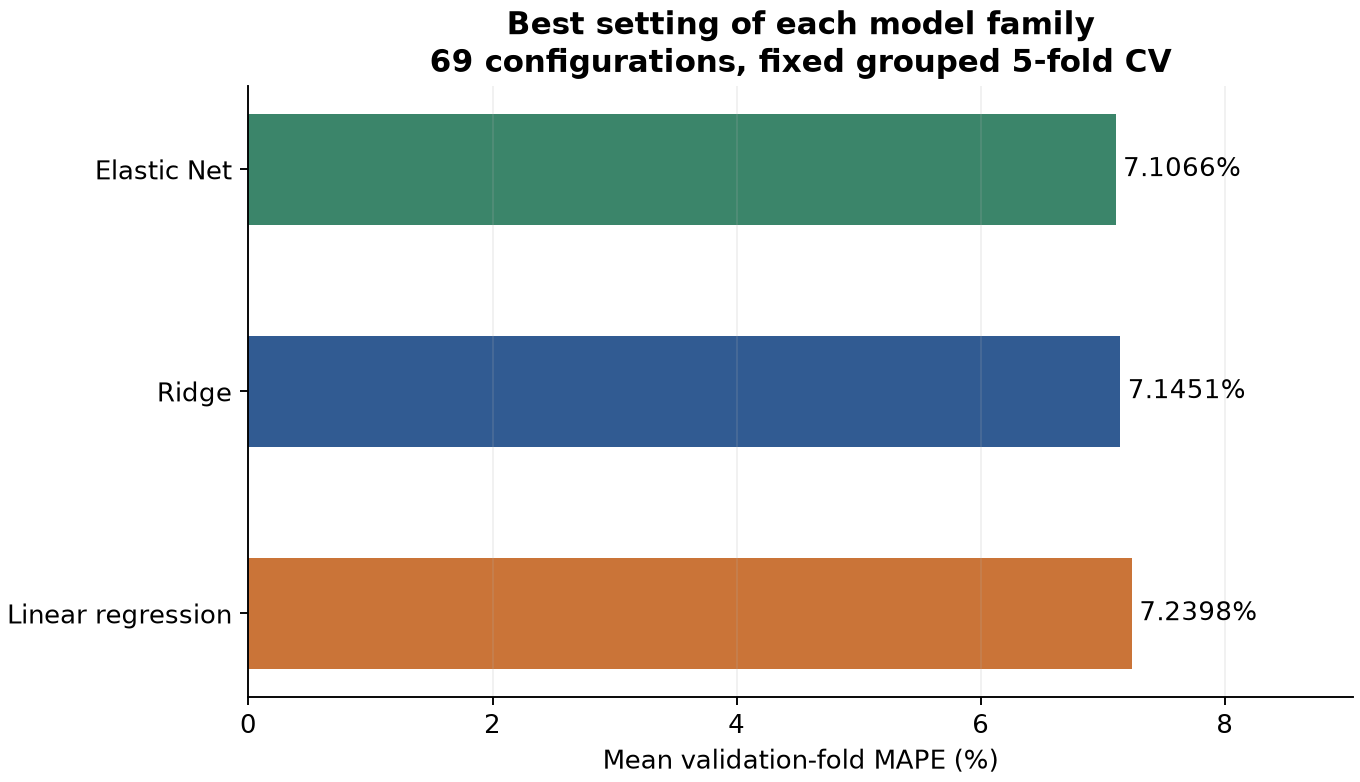

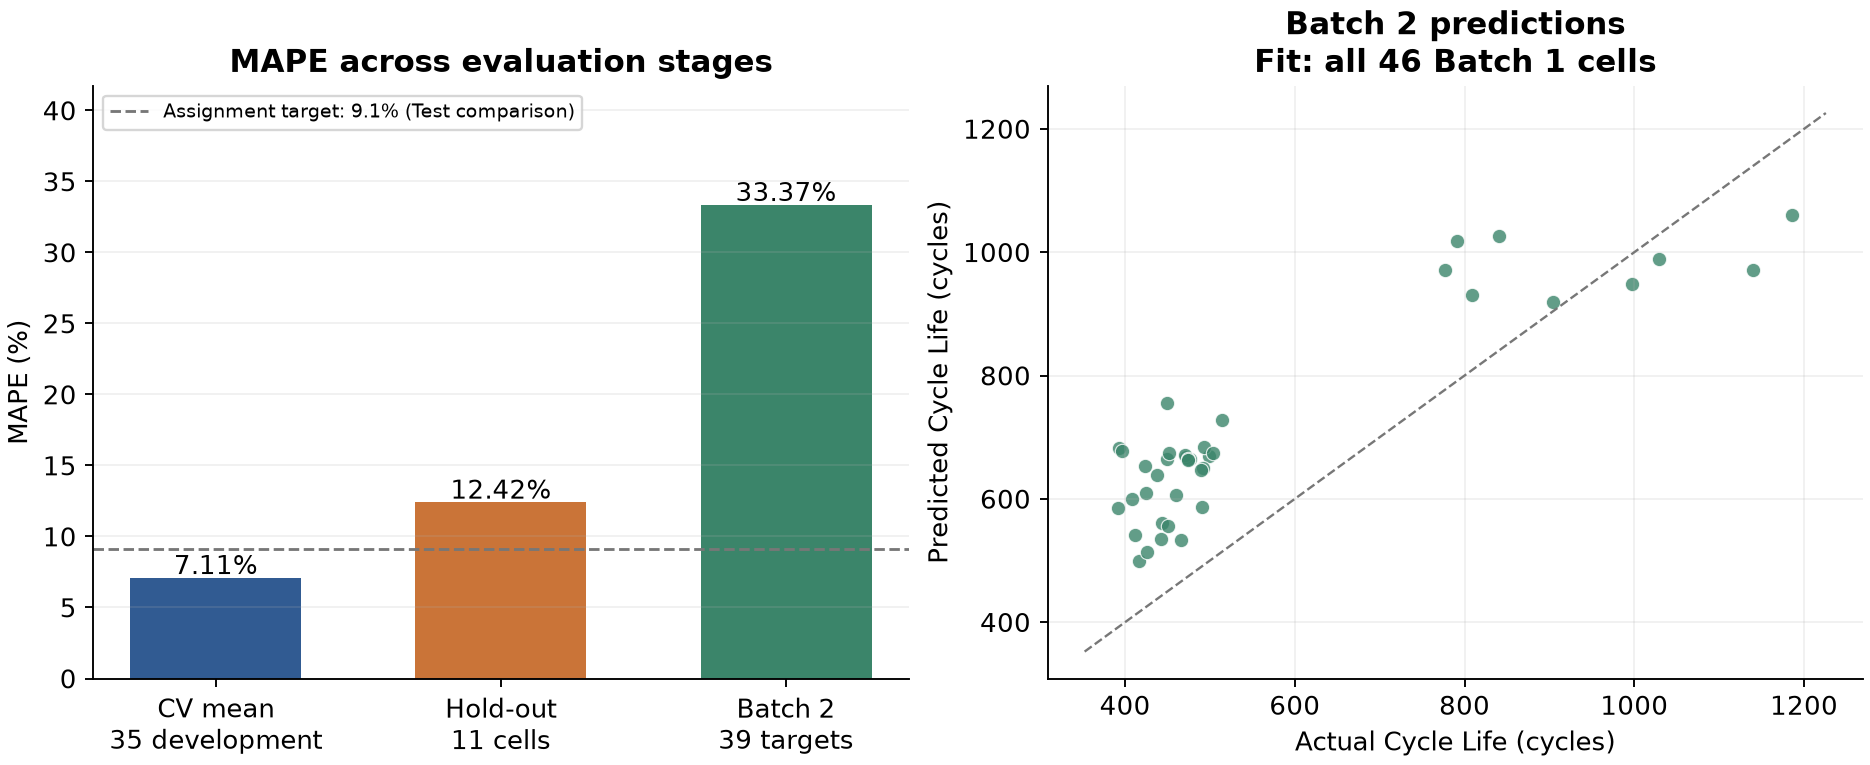

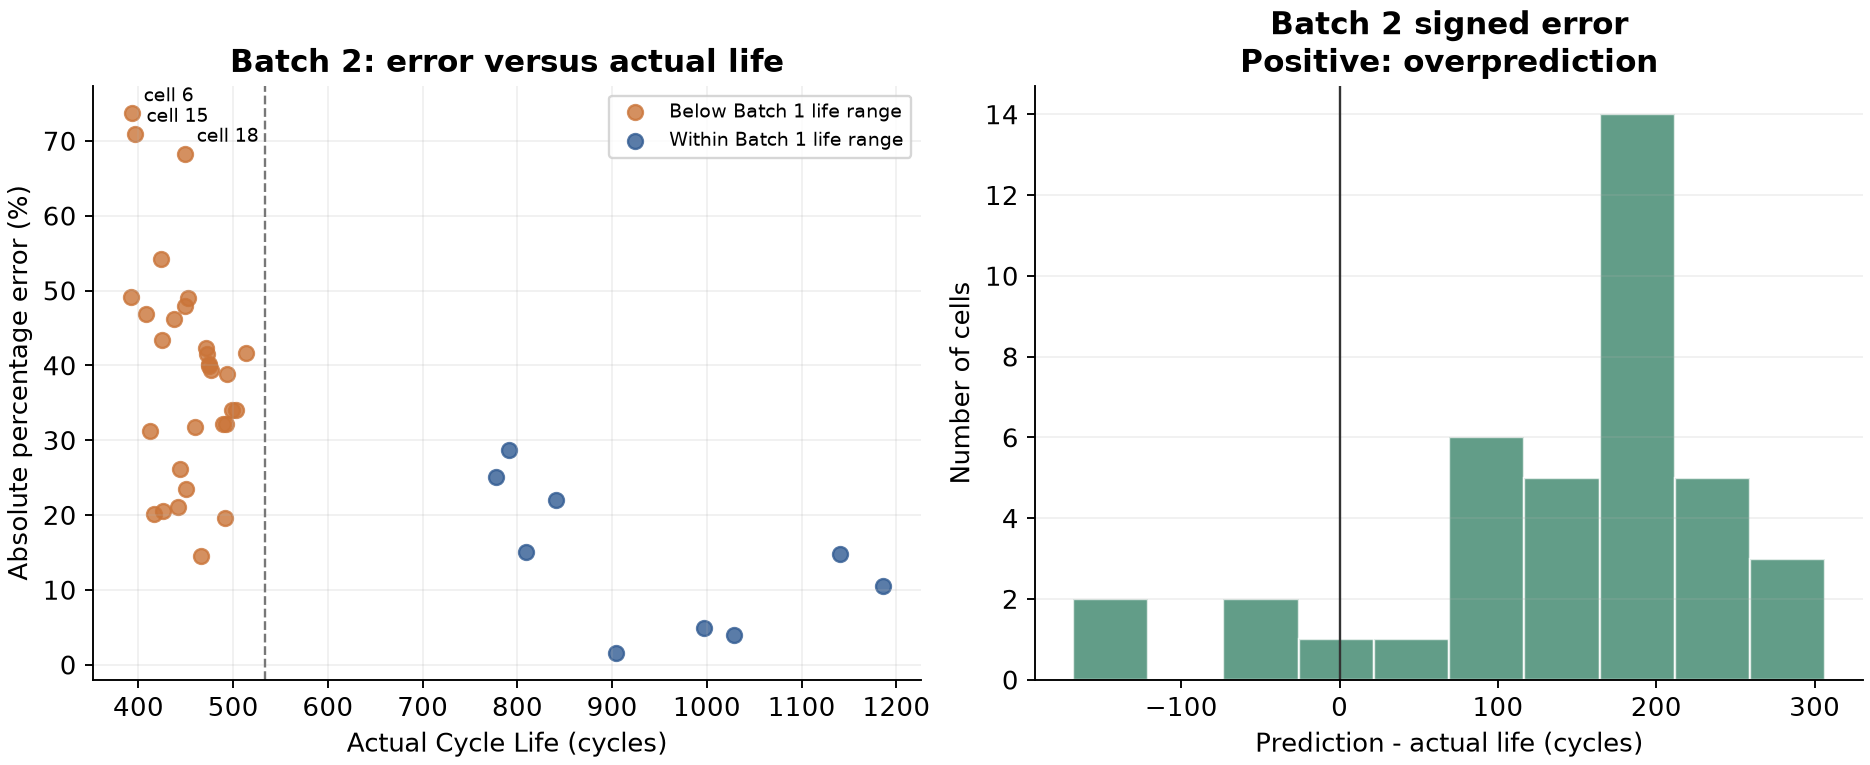

In [5]:
figure_paths = create_figures(ROOT, result)
for path in figure_paths:
    display(Image(filename=str(path), width=1000))

## 4. 오류 분석

최종 Test와 개발 OOF를 구분한다. 큰 APE의 셀을 확인하고 절대 오차, 충전 프로토콜, 입력·수명 범위를 함께 본다.
Batch 2 결과는 성능 보고와 원인 가설에만 사용하며 모델 재선택·재튜닝에 사용하지 않는다.
오류 원인을 확정하거나 성능이 낮다는 이유로 셀을 사후 삭제하지 않는다.

In [6]:
test_predictions = result['batch2_predictions']
scored = test_predictions[np.isfinite(test_predictions['y_true_cycle_life'])].copy()
columns = ['cell_id','policy_readable','delta_q_log10var','y_true_cycle_life',
           'y_pred_cycle_life','absolute_error_cycles','absolute_percentage_error_percent']
display(scored.nlargest(5,'absolute_percentage_error_percent')[columns])
print('원본/평가/미상:', len(test_predictions), len(scored), len(test_predictions)-len(scored))
display(test_predictions[~np.isfinite(test_predictions['y_true_cycle_life'])][['cell_id','policy_readable','y_pred_cycle_life']])
print('개발 모델 식:', summary['development_model_equation'])
print('최종 모델 식:', summary['final_model_equation'])

,cell_id,policy_readable,delta_q_log10var,y_true_cycle_life,y_pred_cycle_life,absolute_error_cycles,absolute_percentage_error_percent
6,6,3.6C(9%)-5C,-3.530040,393.0,682.726681,289.726681,73.721802
15,15,3.6C(9%)-5C,-3.516252,396.0,677.049148,281.049148,70.972007
18,18,5.2C(50%)-4.25C,-3.707303,449.0,755.720178,306.720178,68.311844
2,2,5.2C(50%)-4.25C,-3.460248,424.0,653.987964,229.987964,54.242444
19,19,6C(60%)-3C,-3.291958,392.0,584.689246,192.689246,49.155420


원본/평가/미상: 47 39 8


,cell_id,policy_readable,y_pred_cycle_life
22,22,VarCharge-2C-100cycles,1140.268131
23,23,VarCharge-4C-100cycles,1022.945878
35,35,VarCharge-6C-100cycles,554.609062
36,36,VarCharge-8C-100cycles,334.721828
37,37,3.6C(80%)-3.6C(SLOWCYCLE,1193.569921
38,38,4.8C(80%)-4.8C(SLOWCYCLE,964.924326
39,39,3.6C(9%)-5C(SLOWCYCLE,613.771457
40,40,5.2C(58%)-4C(SLOWCYCLE,711.356798


개발 모델 식: {'stage': 'development_fit', 'n_fit_cells': 35, 'feature': 'delta_q_log10var', 'scaler_mean': -3.8592502375675215, 'scaler_scale': 0.2937398549550416, 'coefficient_standardized': -154.12097902563667, 'intercept_standardized': 828.8857142857144, 'coefficient_original_input_units': -524.6852833410219, 'intercept_original_input_units': -1196.0060900963067, 'equation': 'predicted_cycle_life = -1196.0060901 + (-524.685283341) * delta_q_log10var', 'target_unit': 'cycles', 'prediction_clipping': False}
최종 모델 식: {'stage': 'all_batch1_final_fit', 'n_fit_cells': 46, 'feature': 'delta_q_log10var', 'scaler_mean': -3.9234304460386986, 'scaler_scale': 0.3741384249315887, 'coefficient_standardized': -154.06297127415692, 'intercept_standardized': 844.7173913043479, 'coefficient_original_input_units': -411.7806699547831, 'intercept_original_input_units': -770.875426286461, 'equation': 'predicted_cycle_life = -770.875426286 + (-411.780669955) * delta_q_log10var', 'target_unit': 'cycles', 'predi

## 5. ESS 해석과 재현성

초기 수명 예측은 셀 선별·점검 우선순위·유지보수 계획의 참고 정보가 될 수 있다. 이번 결과는 실험 셀의 총 Cycle Life 회귀이며 현장 BESS의 RUL·안전 위험을 직접 예측하지 않는다.
실제 적용 전 현장 온도·SOC·충방전 조건과 모듈 구성을 검증하고, 외부 성능·불확실성·실패 비용·분포 변화를 확인해야 한다.

정확한 후보·설정·성능·예측은 `artifacts/experiments/v02_submission/`, 실행 설계는 `configs/experiments/v02_submission.json`에 보존한다.
README의 최종 수치·오류 분석과 이 실행 결과를 연결한다. 사용자가 제출하는 링크는 공개 GitHub 저장소다.

In [7]:
print('분할 ID:', summary.get('split_id', result['run_manifest'].get('split_id')))
print('실행 기록: artifacts/experiments/v02_submission/run-manifest.json')
print('최적화: 지정한 69설정의 Grid Search; Optuna 미사용')
print('입력 CSV: outputs/day1/early_feature_candidates.csv')
print('GitHub: https://github.com/LWH4Data/battery-project')

분할 ID: 5ac6e1b0a3010116290b6d6a5675dc54a9ecc17867404b891c2d9989369b9fa1
실행 기록: artifacts/experiments/v02_submission/run-manifest.json
최적화: 지정한 69설정의 Grid Search; Optuna 미사용
입력 CSV: outputs/day1/early_feature_candidates.csv
GitHub: https://github.com/LWH4Data/battery-project
